In [64]:
import pandas as pd
import numpy as np
import sys
sys.path.append("../..")
from analysis import utils as ut
import os
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
import yaml


In [65]:
def timeseries_cf_matrix(axes, i, cpd_data, dmso_data, plot=False, save=False):
    # File paths based on cell type and data type  
    abcd = ['A', 'B', 'C', 'D']
    diag_cms = []
    
       
    cell = dmso_data.Metadata_Cells.unique()[0]
    # Calculate Ycpd and Ydmso
    preds = ['AKT', 'CDK', 'HDAC', 'MAPK', 'PARP', 'TUB']
    Ycpd = np.array([cpd_data[f'smoothed_{p}_pred_early_sum'] + cpd_data[f'smoothed_{p}_pred_late_sum'] for p in preds]).T
    Ydmso = np.array([dmso_data[f'smoothed_{p}_pred_early_sum'] + dmso_data[f'smoothed_{p}_pred_late_sum'] for p in preds]).T
    
    # Calculate limit for each column
    lim = np.quantile(Ydmso, 0.95, axis=0)
    # Determine predictions
    a, b = np.max(Ycpd, axis=1), np.argmax(Ycpd, axis=1)
    MOAs = preds + ["DMSO"]
    PRED = [MOAs[b[i]] if a[i] > lim[b[i]] else MOAs[-1] for i in range(len(a))]
    
    # Create confusion matrix
    cm = confusion_matrix(cpd_data['Metadata_cmpd_moa_group'], PRED, labels=MOAs)
    cm = cm[:-1, :]
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    diag_cms.append(np.diag(cm_percent))
    print(f"Accuracy: {np.trace(cm) / np.sum(cm):.3f}")
    ax = axes[i]
    if plot:
        # Plot confusion matrix
        sns.heatmap(cm_percent*100, annot=True, fmt='.1f', cmap='Blues', xticklabels=MOAs, yticklabels=MOAs[:-1], cbar=False, ax=ax, annot_kws={"size": 17}, square=True)
        ax.set_title(f"{cell[:-3]} - Time series \n Accuracy: {round((np.trace(cm) / np.sum(cm))*100)}%", fontsize=20)
        ax.set_title(f"{abcd[i]}", loc='left', fontweight='bold', fontsize=20)
        ax.set_yticklabels('', size=1)
        ax.set_xticklabels(ax.get_xticklabels(), size=16, rotation=45)
        ax.set_xlabel('Predicted', size=18)        
        ax.set_ylabel(' ')
        i += 1
    return i, axes, cm, diag_cms

In [66]:
def single_time_point_cf_matrix(axes, i, cpd_data, dmso_data, plot=False, save=False):
    
    abcd = ['A', 'B', 'C', 'D']
    diag_cms = []
    
    
    cell = dmso_data.Metadata_Cells.unique()[0]           
    # Calculate Ycpd and Ydmso
    preds = ['AKT', 'CDK', 'HDAC', 'MAPK', 'PARP', 'TUB']
    Ycpd = np.array([cpd_data[f'{p}_pred'] for p in preds]).T
    Ydmso = np.array([dmso_data[f'{p}_pred'] for p in preds]).T
    
    # Calculate limit for each column
    lim = np.quantile(Ydmso, 0.95, axis=0)
    # Determine predictions
    a, b = np.max(Ycpd, axis=1), np.argmax(Ycpd, axis=1)
    MOAs = preds + ["DMSO"]
    PRED = [MOAs[b[i]] if a[i] > lim[b[i]] else MOAs[-1] for i in range(len(a))]
    
    # Create confusion matrix
    cm = confusion_matrix(cpd_data['Metadata_cmpd_moa_group'], PRED, labels=MOAs)
    cm = cm[:-1, :]
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    diag_cms.append(np.diag(cm_percent))
    print(f"Accuracy: {np.trace(cm) / np.sum(cm):.3f}")

    ax = axes[i]
    if plot:
        # Plot confusion matrix
        sns.heatmap(cm_percent*100, annot=True, cmap='Blues', fmt='.1f', xticklabels=MOAs, yticklabels=MOAs[:-1], cbar=False, ax=ax, annot_kws={"size": 17}, square=True)
        if cell == 'U2-OS-WT':
            cell = 'U2OS-WT'
        ax.set_title(f"{cell[:-3]} - Single time point \n Accuracy: {round((np.trace(cm) / np.sum(cm))*100)}%", fontsize=20) #, loc='right')
        ax.set_title(f"{abcd[i]}", loc='left', fontweight='bold', fontsize=20)
        if i == 0:
            ax.set_yticklabels(ax.get_yticklabels(), size=16, rotation=0)
        else:
            ax.set_yticklabels('', size=1)
        ax.set_xticklabels(ax.get_xticklabels(), size=16, rotation=45)

        ax.set_xlabel('Predicted', size=18)
        if i == 0:
            ax.set_ylabel('True', size=18)
        else:
            ax.set_ylabel(' ')
        i += 1
        
    return i, axes, cm, diag_cms

A549-WT
Single time point:
Accuracy: 0.626
U2OS-WT
Single time point:
Accuracy: 0.580
A549-WT
Time series:
Accuracy: 0.776
U2OS-WT
Time series:
Accuracy: 0.745
A549-WT
TtestResult(statistic=np.float64(-4.508293904262154), pvalue=np.float64(0.006350859206425933), df=np.int64(5))
U2OS-WT
TtestResult(statistic=np.float64(-3.9096391294231467), pvalue=np.float64(0.011299089780981392), df=np.int64(5))


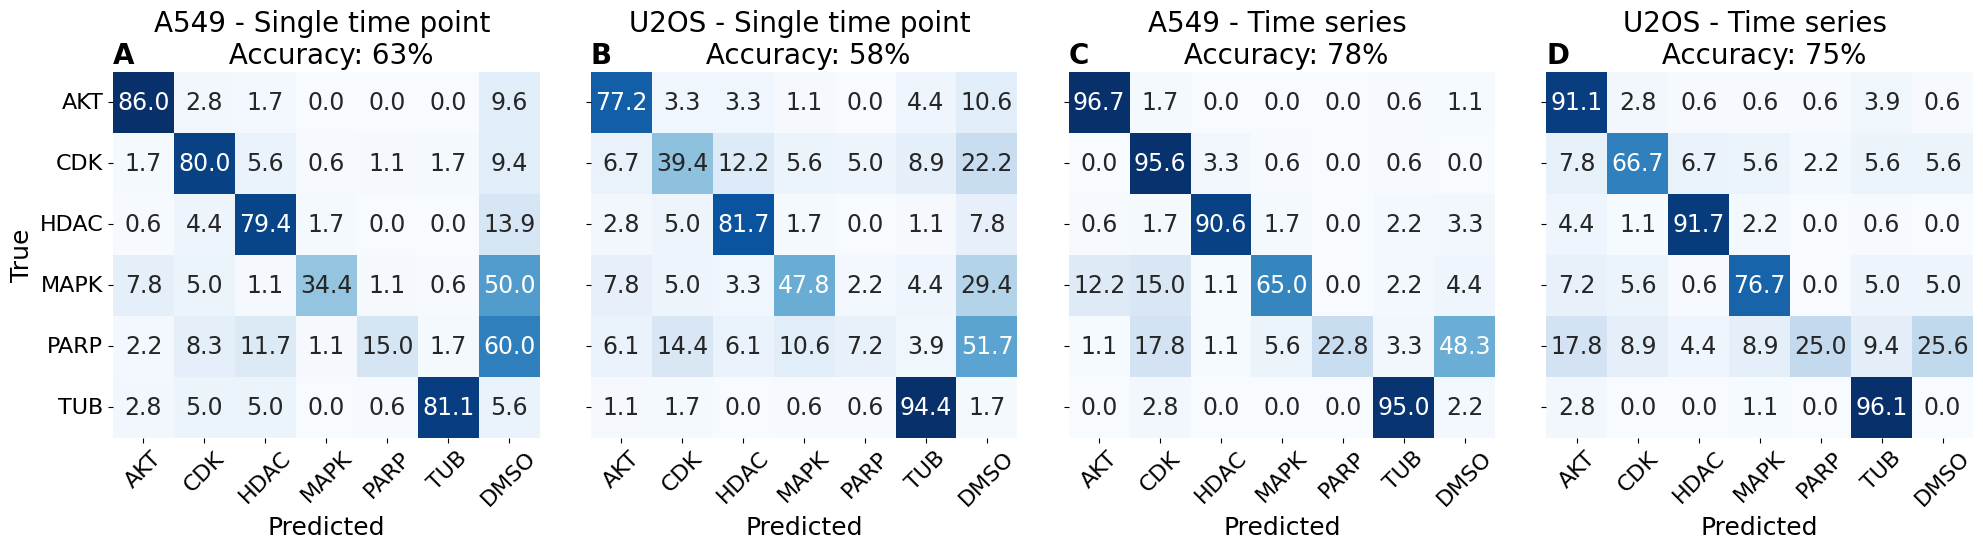

In [69]:

cells = ['A549-WT', 'U2OS-WT']
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes = axes.flatten()
i = 0

cells = ['A549-WT', 'U2OS-WT']
dir_pointer = "../../"
diag_cms_single_timepoints = []
diag_cms_timeseriess = []
for cell in cells:
    config_path = f"{cell}-analysis-datapaths.yaml"
    print(cell)
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    # Load data
    stp_cpd_data = dir_pointer + config['single_timepoint']['single_time_point_analysis_processed']
    stp_dmso_data = dir_pointer + config['single_timepoint']['single_time_point_analysis_dmso_processed']
    print('Single time point:')
    stp_cpd_data = pd.read_parquet(stp_cpd_data)
    stp_dmso_data = pd.read_parquet(stp_dmso_data)
    i, axes, cm, diag_cms_single_timepoint = single_time_point_cf_matrix(axes, i, stp_cpd_data, stp_dmso_data, plot=True)
    diag_cms_single_timepoints.append(diag_cms_single_timepoint[0])
for cell in cells:
    config_path = f"{cell}-analysis-datapaths.yaml"
    print(cell)
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    # Load data
    ts_cpd_data = dir_pointer + config['time_series']['time_series_analysis_processed']
    ts_dmso_data = dir_pointer + config['time_series']['time_series_dmso_processed']
    
    print('Time series:')
    ts_cpd_data = pd.read_parquet(ts_cpd_data)
    ts_dmso_data = pd.read_parquet(ts_dmso_data)
    i, axes, cm, diag_cms_timeseries = timeseries_cf_matrix(axes, i, ts_cpd_data, ts_dmso_data, plot=True)
    diag_cms_timeseriess.append(diag_cms_timeseries[0])
for i in range(len(diag_cms_single_timepoints)):
    print(cells[i])    
    print(ttest_rel(diag_cms_single_timepoints[i], diag_cms_timeseriess[i]))
plt.tight_layout()
plt.savefig(dir_pointer + f"analysis/comparison/cf-matrix.pdf", bbox_inches='tight')
plt.show()
  

A549-WT
Single time point:
Accuracy: 0.606
U2OS-WT
Single time point:
Accuracy: 0.578
A549-WT
Time series:
Accuracy: 0.761
U2OS-WT
Time series:
Accuracy: 0.750
A549-WT
TtestResult(statistic=np.float64(-5.028948456749698), pvalue=np.float64(0.0040044225176640285), df=np.int64(5))
U2OS-WT
TtestResult(statistic=np.float64(-4.274337606832938), pvalue=np.float64(0.007906023218793792), df=np.int64(5))


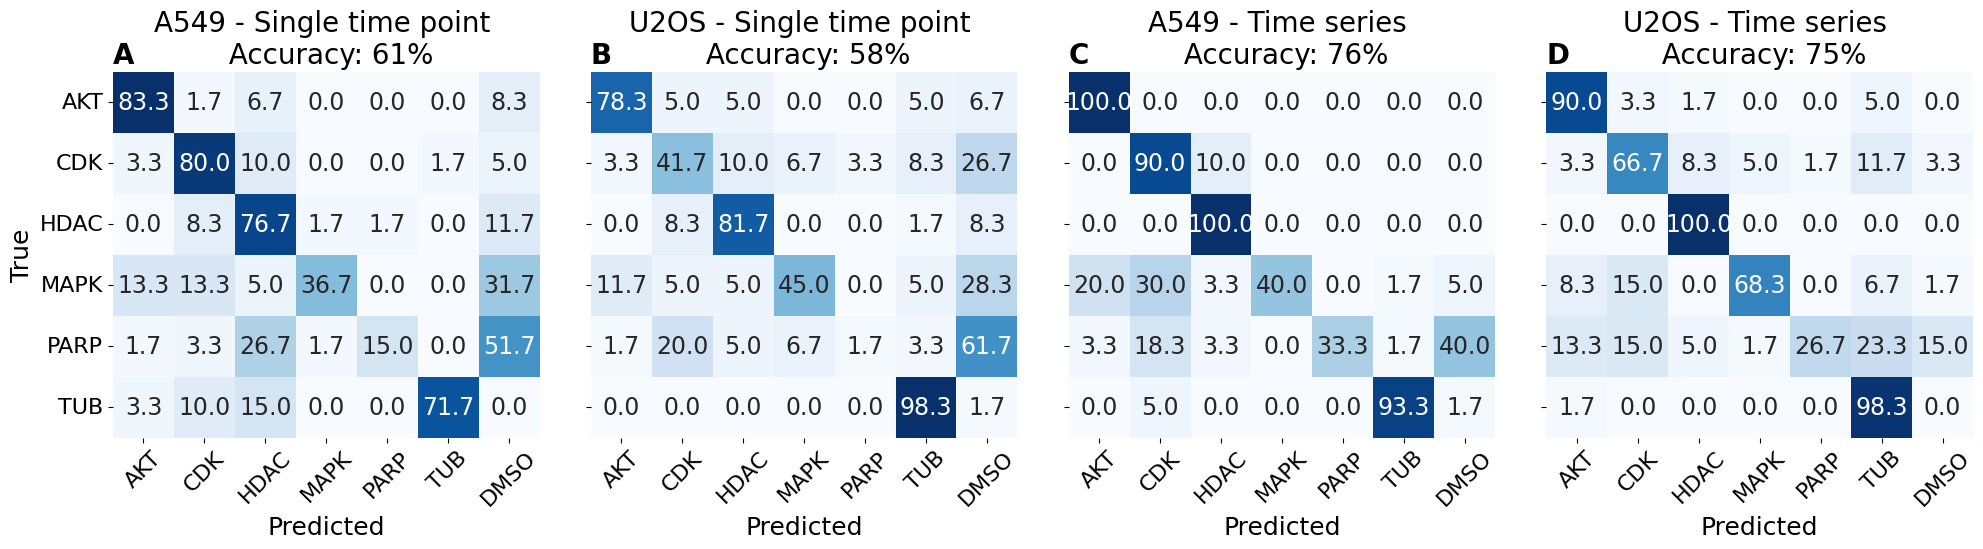

A549-WT
Single time point:
Accuracy: 0.729
U2OS-WT
Single time point:
Accuracy: 0.572
A549-WT
Time series:
Accuracy: 0.822
U2OS-WT
Time series:
Accuracy: 0.714
A549-WT
TtestResult(statistic=np.float64(-2.014457593131227), pvalue=np.float64(0.1000754094914553), df=np.int64(5))
U2OS-WT
TtestResult(statistic=np.float64(-2.415461635488508), pvalue=np.float64(0.060455035143520026), df=np.int64(5))


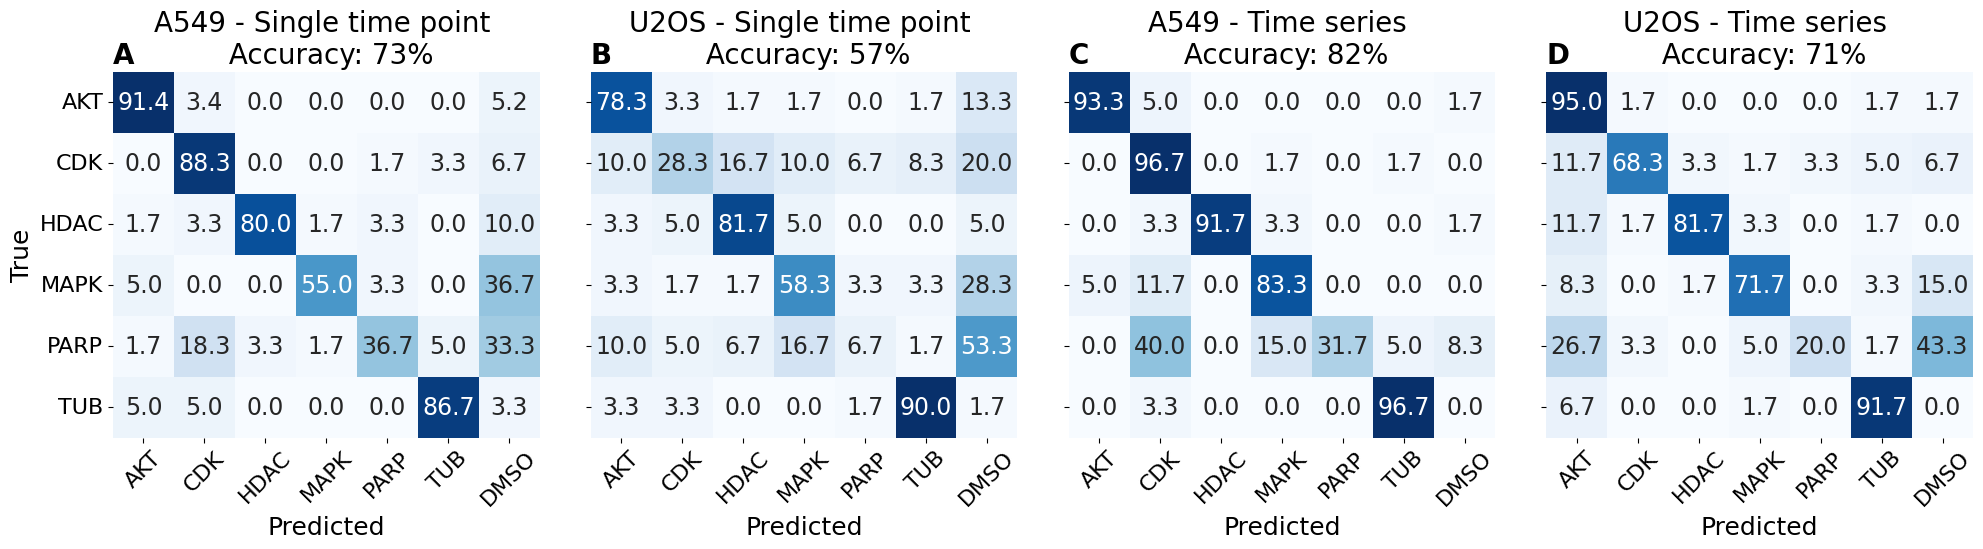

A549-WT
Single time point:
Accuracy: 0.664
U2OS-WT
Single time point:
Accuracy: 0.606
A549-WT
Time series:
Accuracy: 0.772
U2OS-WT
Time series:
Accuracy: 0.761
A549-WT
TtestResult(statistic=np.float64(-2.4956965417496635), pvalue=np.float64(0.054777760051446), df=np.int64(5))
U2OS-WT
TtestResult(statistic=np.float64(-2.0743586421036873), pvalue=np.float64(0.09272437417714513), df=np.int64(5))


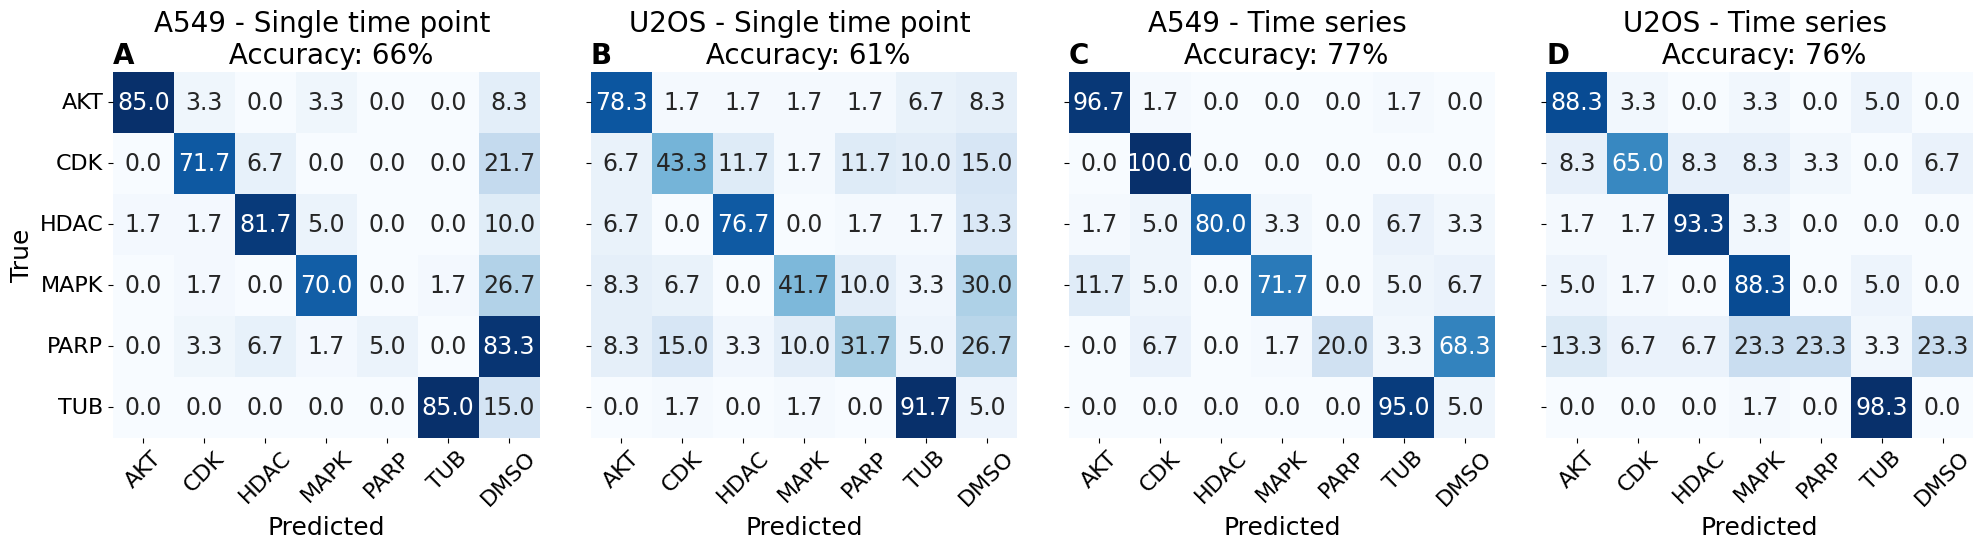

In [68]:

for cv_round_idx in range(3):
    cells = ['A549-WT', 'U2OS-WT']
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes = axes.flatten()
    i = 0

    cells = ['A549-WT', 'U2OS-WT']
    dir_pointer = "../../"
    diag_cms_single_timepoints = []
    diag_cms_timeseriess = []
    for cell in cells:
        config_path = f"{cell}-analysis-datapaths.yaml"
        print(cell)
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        # Load data
        stp_cpd_data = dir_pointer + config['single_timepoint']['single_time_point_analysis_processed']
        stp_dmso_data = dir_pointer + config['single_timepoint']['single_time_point_analysis_dmso_processed']
        print('Single time point:')
        stp_cpd_data = pd.read_parquet(stp_cpd_data)
        stp_dmso_data = pd.read_parquet(stp_dmso_data)
        cv_round = stp_cpd_data['Metadata_cv_seed'].unique()[cv_round_idx]
        i, axes, cm, diag_cms_single_timepoint = single_time_point_cf_matrix(axes, i, stp_cpd_data[stp_cpd_data['Metadata_cv_seed'] == cv_round], stp_dmso_data[stp_dmso_data['Metadata_cv_seed'] == cv_round], plot=True)
        diag_cms_single_timepoints.append(diag_cms_single_timepoint[0])
    for cell in cells:
        config_path = f"{cell}-analysis-datapaths.yaml"
        print(cell)
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        # Load data
        ts_cpd_data = dir_pointer + config['time_series']['time_series_analysis_processed']
        ts_dmso_data = dir_pointer + config['time_series']['time_series_dmso_processed']
        
        print('Time series:')
        ts_cpd_data = pd.read_parquet(ts_cpd_data)
        ts_dmso_data = pd.read_parquet(ts_dmso_data)
        cv_round = ts_cpd_data['Metadata_cv_seed'].unique()[cv_round_idx]
        i, axes, cm, diag_cms_timeseries = timeseries_cf_matrix(axes, i, ts_cpd_data[ts_cpd_data['Metadata_cv_seed'] == cv_round], ts_dmso_data[ts_dmso_data['Metadata_cv_seed'] == cv_round], plot=True)
        diag_cms_timeseriess.append(diag_cms_timeseries[0])
    for i in range(len(diag_cms_single_timepoints)):
        print(cells[i])    
        print(ttest_rel(diag_cms_single_timepoints[i], diag_cms_timeseriess[i]))
    plt.tight_layout()
    # plt.savefig(dir_pointer + f"analysis/comparison/cf-matrix.pdf", bbox_inches='tight')
    plt.show()
    